In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Path of Iris CSV file
file_path = "C:/Users/Kandarp Malkan/OneDrive/Desktop/DL_Material/iris.csv"
# file_path = "Z:/iris.csv" FOR THE LAB/ EXAM ENVIRONMENT

# Load CSV file
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,Id,sepal_length,sepal_width,petal_length,petal_width,species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (150, 6)

Column Names:
Index(['Id', 'sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

First 5 Rows:
   Id  sepal_length  sepal_width  petal_length  petal_width species
0   1           5.1          3.5           1.4          0.2  setosa
1   2           4.9          3.0           1.4          0.2  setosa
2   3           4.7          3.2           1.3          0.2  setosa
3   4           4.6          3.1           1.5          0.2  setosa
4   5           5.0          3.6           1.4          0.2  setosa


In [4]:
# Input features
X = df[
    ["sepal_length",
     "sepal_width",
     "petal_length",
     "petal_width"]
]

# Target
y = df["species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded Classes:")
print(y_encoded[:10])

print("\nClass Names:")
print(label_encoder.classes_)

Encoded Classes:
[0 0 0 0 0 0 0 0 0 0]

Class Names:
['setosa' 'versicolor' 'virginica']


In [6]:
# As we have multiclass classification problem we need to convert (setosa, virginica) -> label -> one hot encoding (as using categorical cross entropy)
y_onehot = tf.keras.utils.to_categorical(
    y_encoded,
    num_classes=3
)

y_onehot[:5] #(to see the different one hot encoding for the given classes )

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]], dtype=float32)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_onehot,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (120, 4)
Testing data : (30, 4)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [9]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dense(8,activation="relu"),
    tf.keras.layers.Dense(3,activation="softmax")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                80        
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 3)                 27        
                                                                 
Total params: 243
Trainable params: 243
Non-trainable params: 0
_________________________________________________________________


In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
6/6 [==============================] - 2s 92ms/step - loss: 0.8289 - accuracy: 0.6354 - val_loss: 0.7581 - val_accuracy: 0.7500
Epoch 2/20
6/6 [==============================] - 0s 15ms/step - loss: 0.8026 - accuracy: 0.6354 - val_loss: 0.7377 - val_accuracy: 0.7500
Epoch 3/20
6/6 [==============================] - 0s 13ms/step - loss: 0.7791 - accuracy: 0.6354 - val_loss: 0.7189 - val_accuracy: 0.7500
Epoch 4/20
6/6 [==============================] - 0s 11ms/step - loss: 0.7568 - accuracy: 0.6354 - val_loss: 0.7002 - val_accuracy: 0.7500
Epoch 5/20
6/6 [==============================] - 0s 12ms/step - loss: 0.7351 - accuracy: 0.6354 - val_loss: 0.6819 - val_accuracy: 0.7500
Epoch 6/20
6/6 [==============================] - 0s 11ms/step - loss: 0.7166 - accuracy: 0.6354 - val_loss: 0.6635 - val_accuracy: 0.7500
Epoch 7/20
6/6 [==============================] - 0s 11ms/step - loss: 0.6976 - accuracy: 0.6354 - val_loss: 0.6475 - val_accuracy: 0.7500
Epoch 8/20
6/6 [===========

In [12]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)

print(
    "Test Accuracy: {:.2f}%".format(
        test_accuracy * 100
    )
)

Test Loss: 0.5586474537849426
Test Accuracy: 63.33%


In [ ]:
y_pred_probability = model.predict(X_test)

# Convert probabilities into class numbers
y_pred = np.argmax(
    y_pred_probability,
    axis=1
) # use of argmax : a mathematical operation that finds the input value where a function reaches its highest output

# Convert actual one-hot values into class numbers
y_actual = np.argmax(
    y_test,
    axis=1
)

print("Predicted Classes:")
print(y_pred)

print("\nActual Classes:")
print(y_actual)

Predicted Classes:
[0 2 1 1 0 2 0 0 2 1 2 2 2 2 0 0 0 1 2 2 0 2 2 2 2 2 2 0 2 0]

Actual Classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [16]:
print("Class Mapping:")

for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Class Mapping:
0 = setosa
1 = versicolor
2 = virginica


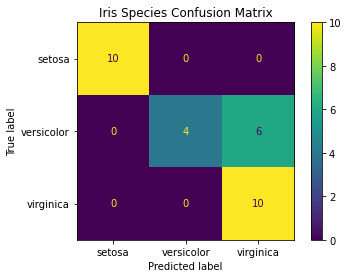

In [ ]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("Iris Species Confusion Matrix")

plt.show()